# Clue-giver attempt timestamps

Reads `transcripts_all.csv` and, per trial, extracts the **timestamps of each clue-giver attempt**
to explain the target term — so those intervals can be used to slice and compare the multimodal
signals (merged video, motion tracking, acoustics, sway) attempt-by-attempt. `start`/`end` are
seconds from trial start, the same clock as the other modalities.

**Definitions (as chosen):**
- **Turns are chronological.** All of a trial's segments are ordered by `start`; a new turn begins
  whenever `role` changes. A guesser interjection (even overlapping) ends the current clue-giver
  attempt.
- **Attempts run up to the correct guess.** An attempt is a clue-giver turn that *starts before* the
  first mention of the target word (the guess). Trials where the target word never appears keep all
  clue-giver turns and are flagged `guessed = False`.

Outputs (written next to this notebook): `clue_giver_attempts.csv` (one row per attempt) and
`trial_turntaking_summary.csv` (one row per trial).

In [51]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
SRC = HERE / "transcripts_all.csv"
ATTEMPTS_CSV = HERE / "clue_giver_attempts.csv"
SUMMARY_CSV = HERE / "trial_turntaking_summary.csv"

df = pd.read_csv(SRC)
df["text"] = df["text"].fillna("").astype(str)
print(f"{len(df)} segment rows across {df['trial_id'].nunique()} trials")

def says_target(text, target):
    """True if `text` contains the target word (case-insensitive, exact or simple plural/singular)."""
    target = str(target).lower()
    for tok in re.findall(r"[a-z']+", str(text).lower()):
        if tok == target or (tok.rstrip("s") == target.rstrip("s") and abs(len(tok) - len(target)) <= 2):
            return True
    return False

623 segment rows across 120 trials


In [52]:
def glue_turns(trial):
    """Order a trial's segments by time and glue consecutive same-role segments into turns."""
    turns = []
    for r in trial.sort_values(["start", "end"]).itertuples(index=False):
        if turns and r.role == turns[-1]["role"]:
            t = turns[-1]
            t["end"] = max(t["end"], r.end)          # max: segments can overlap or nest
            t["text"] = (t["text"] + " " + r.text).strip()
            t["n_segments"] += 1
        else:
            turns.append({"role": r.role, "participant_id": r.participant_id,
                          "start": r.start, "end": r.end,
                          "text": r.text.strip(), "n_segments": 1})
    return turns


def find_guess(trial, target):
    """(start, text) of the earliest segment saying the target word, else (None, "")."""
    hits = trial[trial["text"].apply(lambda t: says_target(t, target))].sort_values("start")
    if hits.empty:
        return None, ""
    return float(hits["start"].iloc[0]), hits["text"].iloc[0]


def process_trial(trial):
    """Return (attempt_rows, summary_row) for one trial."""
    meta = trial.iloc[0]

    def participant(role):                            # None if that role never spoke
        ids = trial.loc[trial.role == role, "participant_id"]
        return int(ids.iloc[0]) if len(ids) else None

    guess_time, guess_text = find_guess(trial, meta.target_word)
    cutoff = guess_time if guess_time is not None else np.inf   # no guess -> keep everything

    kept = [t for t in glue_turns(trial) if t["start"] < cutoff]      # turns before the guess
    attempts = [t for t in kept if t["role"] == "clue_giver"]         # ...that are the clue giver's
    turntakes = sum(a["role"] != b["role"] for a, b in zip(kept, kept[1:]))  # speaker changes

    common = {"trial_id": meta.trial_id, "pair_id": meta.pair_id, "condition": meta.condition,
              "target_word": meta.target_word, "clue_giver_id": participant("clue_giver")}

    attempt_rows = [
        {**common, "attempt_idx": i, "n_attempts": len(attempts),
         "start": round(t["start"], 3), "end": round(t["end"], 3),
         "duration": round(t["end"] - t["start"], 3),
         "n_segments": t["n_segments"], "text": t["text"]}
        for i, t in enumerate(attempts, start=1)
    ]

    summary_row = {
        **common, "guesser_id": participant("guesser"),
        "n_clue_giver_attempts": len(attempts), "n_turns_total": len(kept),
        "n_turntakes": turntakes, "guessed": guess_time is not None,
        "guess_time": round(guess_time, 3) if guess_time is not None else None,
        "guess_text": guess_text,
    }
    return attempt_rows, summary_row

In [53]:
attempt_rows, summary_rows = [], []
for _tid, trial in df.groupby("trial_id", sort=True):
    a, s = process_trial(trial)
    attempt_rows.extend(a)
    summary_rows.append(s)

attempts = pd.DataFrame(attempt_rows)
summary = pd.DataFrame(summary_rows)

attempts.to_csv(ATTEMPTS_CSV, index=False)
summary.to_csv(SUMMARY_CSV, index=False)

print(f"{len(summary)} trials  |  {int(summary['guessed'].sum())} guessed, "
      f"{int((~summary['guessed']).sum())} not guessed")
print(f"{len(attempts)} clue-giver attempts total "
      f"(mean {summary['n_clue_giver_attempts'].mean():.1f} per trial)")
print(f"wrote {ATTEMPTS_CSV.name} and {SUMMARY_CSV.name}")
attempts.head()

120 trials  |  64 guessed, 56 not guessed
185 clue-giver attempts total (mean 1.5 per trial)
wrote clue_giver_attempts.csv and trial_turntaking_summary.csv


,trial_id,pair_id,condition,target_word,clue_giver_id,attempt_idx,n_attempts,start,end,duration,n_segments,text
0,103_203_12_1_20250113_152455_doughnut_board,103_203,board,doughnut,103,1,1,1.01,13.79,12.78,4,"Okay, it's like something sweet like a Like th..."
1,103_203_13_1_20250113_152513_spinach_board,103_203,board,spinach,103,1,1,2.80,13.80,11.00,1,"Uh, oh no. It's like, I think Lattice, but not..."
2,103_203_14_1_20250113_152536_balloon_board,103_203,board,balloon,103,1,2,2.61,18.61,16.00,6,"It's latex. You, um... No, you sort of like......"
3,103_203_14_1_20250113_152536_balloon_board,103_203,board,balloon,103,2,2,20.61,22.61,2.00,1,Yeah.
4,103_203_15_1_20250113_152557_bacon_board,103_203,board,bacon,103,1,3,1.20,6.08,4.88,1,"Okay, it's a type of meat comes from an animal..."


## Spot check

In [54]:
for key in ("doughnut_board", "exam_ground"):
    tid = next(t for t in summary["trial_id"] if key in t)
    row = summary[summary.trial_id == tid].iloc[0]
    print(f"\n{tid}\n  target={row.target_word!r}  guessed={row.guessed}  "
          f"guess_time={row.guess_time}  attempts={row.n_clue_giver_attempts}  turntakes={row.n_turntakes}")
    print(attempts[attempts.trial_id == tid][["attempt_idx", "start", "end", "duration", "text"]]
          .to_string(index=False))


103_203_12_1_20250113_152455_doughnut_board
  target='doughnut'  guessed=True  guess_time=14.46  attempts=1  turntakes=0
 attempt_idx  start   end  duration                                                                                                                text
           1   1.01 13.79     12.78 Okay, it's like something sweet like a Like think bread, but sweet Like that and then has another one in the middle

103_203_30_1_20250113_153310_exam_ground
  target='exam'  guessed=False  guess_time=nan  attempts=1  turntakes=0
 attempt_idx  start   end  duration                                                                                                       text
           1   0.88 12.88      12.0 You have to sit them. You don't really like them. They come at the end of the year in university and yeah.


## Distribution of clue-giver attempts per trial

attempts per trial — mean 1.5, median 1, range 0–8


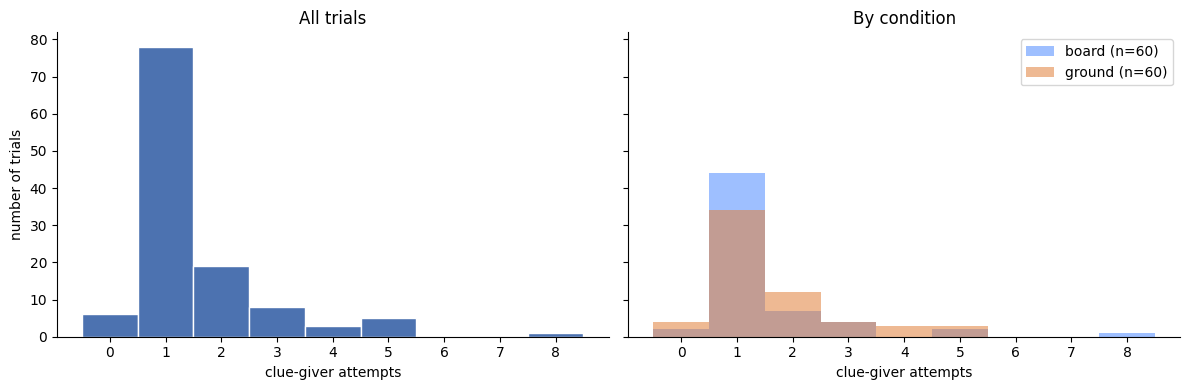

In [55]:
n = summary["n_clue_giver_attempts"]
print(f"attempts per trial — mean {n.mean():.1f}, median {n.median():.0f}, range {n.min()}–{n.max()}")

bins = range(int(n.min()), int(n.max()) + 2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(n, bins=bins, align="left", edgecolor="white", color="#4C72B0")
axes[0].set_title("All trials")
axes[0].set_xlabel("clue-giver attempts"); axes[0].set_ylabel("number of trials")

colors = {"board": "#4f8cff", "ground": "#e0803a"}
for cond, sub in summary.groupby("condition"):
    axes[1].hist(sub["n_clue_giver_attempts"], bins=bins, align="left", alpha=0.55,
                 label=f"{cond} (n={len(sub)})", color=colors.get(cond))
axes[1].set_title("By condition"); axes[1].set_xlabel("clue-giver attempts"); axes[1].legend()

for ax in axes:
    ax.set_xticks(list(bins)[:-1]); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Slice / plot a multimodal series by attempt

**`plot_by_attempts(trial_id, series, time_col, value_col, time_unit, label)`** — give it one
time-series plus a trial (whose attempt/turn-take split was computed above) and it slices the signal
by attempt, prints a per-attempt table (mean / peak / n samples), plots it with the attempts shaded
and the guess marked, and returns `(tagged_df, stats)`.

Building blocks: `attempt_intervals(trial_id)` for the intervals, `assign_attempts(...)` to tag rows
with their `attempt`. Signal loaders `clue_giver_wrist_speed(trial_id)` and
`speech_envelope(trial_id)` are provided; any DataFrame with a time column and a value column works
(`time_unit="s"` or `"ms"`).

103_203_15_1_20250113_152557_bacon_board
per-attempt dyad_wrist_speed:
           mean    peak  n_samples
attempt                           
1.0      0.0480  0.1331        147
2.0      0.0904  0.3140        158
3.0      0.1714  0.6734         75


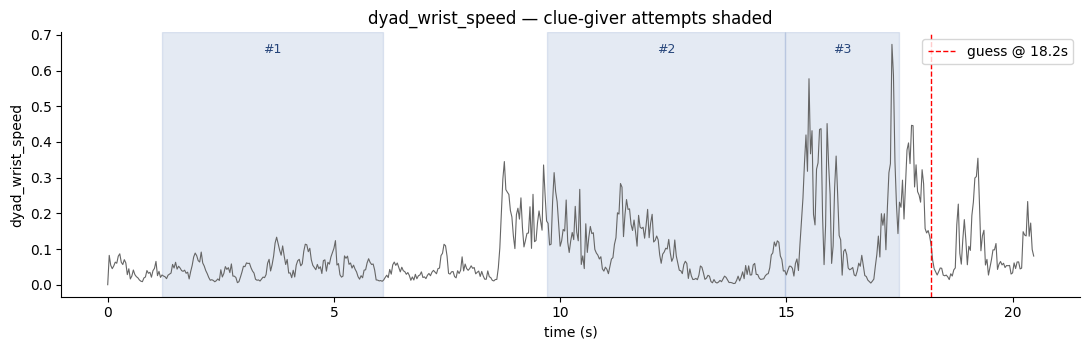

In [56]:
# ---- Slice / plot ANY single time-series by clue-giver attempt ------------
CORPUS = HERE.parent                                   # .../Datasets/BalanceCorpus
MOTION = CORPUS / "motiontracking" / "Output_TimeSeries"
TS_AC = CORPUS / "TS_acoustics"

def attempt_intervals(trial_id):
    """Attempts for one trial: DataFrame [attempt_idx, start, end, duration, text]."""
    cols = ["attempt_idx", "start", "end", "duration", "text"]
    return (attempts.loc[attempts.trial_id == trial_id, cols]
            .sort_values("start").reset_index(drop=True))

def assign_attempts(series, time_col, trial_id, time_unit="s"):
    """Copy of `series` with a `t_sec` column and an `attempt` column (the attempt_idx each row
    falls in, NaN outside any attempt). `time_unit` is 's' or 'ms' for the series' time column."""
    s = series.copy()
    t = s[time_col].to_numpy() / (1000.0 if time_unit == "ms" else 1.0)
    s["t_sec"] = t
    s["attempt"] = np.nan
    for r in attempt_intervals(trial_id).itertuples(index=False):
        s.loc[(t >= r.start) & (t < r.end), "attempt"] = r.attempt_idx
    return s

def plot_by_attempts(trial_id, series, time_col, value_col, time_unit="s",
                     label=None, ax=None, color="0.4", lw=0.8, show_stats=True):
    """Slice ONE time-series by a trial's clue-giver attempts (the turn-take split computed
    above), plot it with the attempts shaded and the guess marked, and return
    (tagged_df, per_attempt_stats).

    trial_id  : which trial's attempt split to use
    series    : DataFrame holding a time column and a value column
    time_col  : name of the time column       time_unit : 's' or 'ms'
    value_col : name of the signal column     label     : y-axis label (defaults to value_col)
    """
    label = label or value_col
    tagged = assign_attempts(series[[time_col, value_col]], time_col, trial_id, time_unit=time_unit)
    stats = (tagged.dropna(subset=["attempt"]).groupby("attempt")[value_col]
             .agg(mean="mean", peak="max", n_samples="count").round(4))
    if show_stats:
        print(f"{trial_id}\nper-attempt {label}:")
        print(stats.to_string())

    iv = attempt_intervals(trial_id)
    gt = summary.loc[summary.trial_id == trial_id, "guess_time"].iloc[0]
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 3.6))
    ax.plot(tagged["t_sec"], tagged[value_col], color=color, lw=lw)
    top = ax.get_ylim()[1]
    for r in iv.itertuples(index=False):
        ax.axvspan(r.start, r.end, alpha=0.15, color="#4C72B0")
        ax.text((r.start + r.end) / 2, top * 0.92, f"#{int(r.attempt_idx)}",
                ha="center", fontsize=9, color="#26457a")
    if pd.notna(gt):
        ax.axvline(gt, color="red", ls="--", lw=1, label=f"guess @ {gt:.1f}s")
        ax.legend(loc="upper right")
    ax.set_xlabel("time (s)"); ax.set_ylabel(label)
    ax.set_title(f"{label} — clue-giver attempts shaded")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    return tagged, stats


# --- signal loaders (each returns a DataFrame with a time col + one value col) ---

def wrist_speed(trial_id):
    """Summed wrist speed of BOTH participants (clue giver + guesser) from cam01 body
    tracking. Normalized frame units / s; `time` in ms on the clue-giver's grid."""

    def wrist_speed(path):
        body = pd.read_csv(path)
        t = body["time"].to_numpy() / 1000.0
        def sp(x, y):
            dx = np.diff(x, prepend=x[0]); dy = np.diff(y, prepend=y[0])
            return np.sqrt(dx * dx + dy * dy)
        dt = np.diff(t, prepend=t[0]); dt[dt == 0] = np.nan
        v = np.nan_to_num(
            (sp(body["X_LEFT_WRIST"].to_numpy(), body["Y_LEFT_WRIST"].to_numpy())
             + sp(body["X_RIGHT_WRIST"].to_numpy(), body["Y_RIGHT_WRIST"].to_numpy())) / 2 / dt)
        return t, v

    p_gu = MOTION / f"{trial_id}_guesser_cam01_body.csv"
    if not p_gu.exists():
        raise FileNotFoundError(f"no guesser motion tracking for {trial_id}")

    t_cg, v_cg = wrist_speed(MOTION / f"{trial_id}_clueGiver_cam01_body.csv")
    t_gu, v_gu = wrist_speed(p_gu)
    v_gu = np.interp(t_cg, t_gu, v_gu)        # grids often differ -> resample onto the CG's
    return pd.DataFrame({"time": t_cg * 1000.0, "dyad_wrist_speed": v_cg + v_gu})


def speech_envelope(trial_id):
    """Normalized amplitude envelope of the mixed dyad audio; time in ms @ 500 Hz."""
    return pd.read_csv(TS_AC / f"env_{trial_id}.wav_norm.csv", usecols=["time", "envelope_norm"])


# --- demo 1: clue-giver wrist speed (gesture) ------------------------------
DEMO_TRIAL = "103_203_15_1_20250113_152557_bacon_board"   # 3 attempts, guessed
_tagged, _stats = plot_by_attempts(DEMO_TRIAL, wrist_speed(DEMO_TRIAL),
                                   "time", "dyad_wrist_speed", time_unit="ms",
                                   label="dyad_wrist_speed")
plt.show()

### Speech envelope per attempt

The same slicing applied to the normalized amplitude envelope
(`TS_acoustics/env_{trial_id}.wav_norm.csv`, `time` in **ms** at 500 Hz, value column
`envelope_norm`).

Note this envelope comes from the **mixed dyad audio** — one file per trial, not split by speaker —
so during a clue-giver attempt it mostly reflects the clue giver, but any overlapping guesser speech
contributes too.

103_203_15_1_20250113_152557_bacon_board
per-attempt normalized speech envelope:
           mean    peak  n_samples
attempt                           
1.0      0.1459  0.5683       2440
2.0      0.0910  0.6172       2630
3.0      0.1804  0.5443       1250


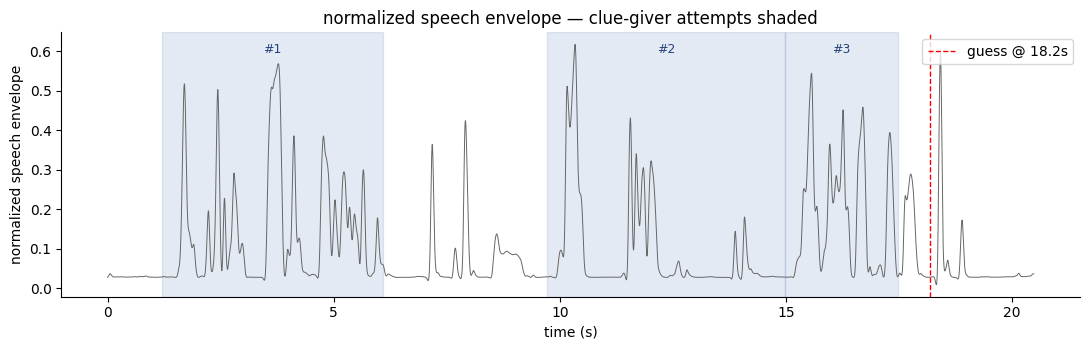

In [57]:
# --- demo 2: normalized speech envelope, same function ---------------------
env_tagged, env_stats = plot_by_attempts(DEMO_TRIAL, speech_envelope(DEMO_TRIAL),
                                         "time", "envelope_norm", time_unit="ms",
                                         label="normalized speech envelope", lw=0.7)
plt.show()

## RQA by attempt

**`rqa_by_attempts(trial_id, series, time_col, value_col, time_unit, label, target_recurrence,
max_points)`** — builds **one** recurrence matrix for the whole trial (so the threshold is shared and
attempts are directly comparable), scores each attempt window on it, draws the recurrence plot with
the attempt windows **boxed on the diagonal** and the guess marked, and returns
`(metrics_df, matrix, t_sec)`.

It reuses the scripts: `calculate_recurrence_matrix` / `calculate_window_metrics` from
`dims/opt/step_RQA.py` (the same core behind the dashboard) and `decimate` from `rqa_attempts.py`.
The line of identity is excluded — it is trivially recurrent in single-series RQA. Long signals are
decimated to `max_points` because the matrix is O(n²).

For the same thing across **all** trials in one go, run the batch script:
`python rqa_attempts.py --signal wrist_speed` (or `--signal envelope`).

In [58]:
import sys

# ---- RQA by attempt: EMBEDDED whole-trial recurrence matrix + per-attempt metrics ---
# Uses the time-delay (Takens) embedded version of the batch script.
sys.path.insert(0, str(HERE / "dims" / "opt"))
from step_RQA import calculate_window_metrics
sys.path.insert(0, str(HERE))
from rqa_attempts_embedded import (decimate, embedded_recurrence_matrix,
                                   estimate_delay, estimate_dimension)

def rqa_by_attempts(trial_id, series, time_col, value_col, time_unit="s", label=None,
                    target_recurrence=0.07, max_points=2000, dim=None, delay=None,
                    plot=True, cmap="Greys"):
    """Build ONE time-delay-embedded recurrence matrix for the trial's signal (shared
    threshold, so the attempts are comparable), score each clue-giver attempt window on it,
    and draw the recurrence plot with those windows boxed on the diagonal.

    dim / delay : embedding parameters; None = estimate from this trial (FNN / AMI).
    Returns (metrics_df, matrix, t_emb).
    """
    label = label or value_col
    s = series[[time_col, value_col]].dropna()
    t = s[time_col].to_numpy() / (1000.0 if time_unit == "ms" else 1.0)
    v = s[value_col].to_numpy()
    t, v = decimate(t, v, max_points=max_points)          # keep the n x n matrix tractable
    if len(t) < 20 or np.std(v) == 0:
        raise ValueError(f"{trial_id}: signal too short or flat for RQA")

    tau = delay or estimate_delay(v)                      # first AMI minimum
    m = dim or estimate_dimension(v, tau)                 # false nearest neighbours
    matrix, threshold, actual_rr, n_vec = embedded_recurrence_matrix(
        v, m, tau, target_recurrence)
    t_emb = t[:n_vec]        # embedded vector i is anchored at t[i]; last (m-1)*tau lost
    dt = float(np.median(np.diff(t_emb))) if len(t_emb) > 1 else 0.033

    rows = []
    for a in attempt_intervals(trial_id).itertuples(index=False):
        idx = np.where((t_emb >= a.start) & (t_emb < a.end))[0]
        if len(idx) < 2:
            continue                                       # window too short to score
        i0, i1 = idx[0], idx[-1] + 1
        # Exclude the line of identity: trivially recurrent, would dominate DET / L_MAX.
        rr, det, lam, l_max = calculate_window_metrics(matrix[i0:i1, i0:i1], dt,
                                                       exclude_main_diagonal=True)
        rows.append({"attempt_idx": int(a.attempt_idx), "start": a.start, "end": a.end,
                     "duration": round(a.end - a.start, 3), "n_points": len(idx),
                     "emb_dim": m, "emb_delay": tau,
                     "RR": round(rr, 4), "DET": round(det, 4),
                     "LAM": round(lam, 4), "L_MAX": round(l_max, 4)})
    metrics = pd.DataFrame(rows)

    if plot:
        gt = summary.loc[summary.trial_id == trial_id, "guess_time"].iloc[0]
        _, ax = plt.subplots(figsize=(7, 7))
        ax.imshow(matrix, origin="lower", cmap=cmap, interpolation="nearest",
                  extent=[t_emb[0], t_emb[-1], t_emb[0], t_emb[-1]])
        for a in metrics.itertuples(index=False):
            side = a.end - a.start
            ax.add_patch(plt.Rectangle((a.start, a.start), side, side, fill=False,
                                       edgecolor="#4f8cff", lw=1.8))
            ax.text(a.end, a.start, f" #{a.attempt_idx}", color="#1d3f80",
                    fontsize=10, va="bottom", fontweight="bold")
        if pd.notna(gt):
            ax.axvline(gt, color="red", ls="--", lw=1)
            ax.axhline(gt, color="red", ls="--", lw=1, label=f"guess @ {gt:.1f}s")
            ax.legend(loc="lower right")
        ax.set_xlabel("time (s)"); ax.set_ylabel("time (s)")
        ax.set_title(f"Recurrence plot (embedded m={m}, τ={tau}) — {label}\n{trial_id}\n"
                     f"threshold={threshold:.3f}, whole-trial RR={actual_rr*100:.1f}%")
        plt.tight_layout()
        print(f"per-attempt RQA metrics ({label}, m={m}, τ={tau}):")
        print(metrics.to_string(index=False))
    return metrics, matrix, t_emb


per-attempt RQA metrics (dyad_wrist_speed, m=8, τ=10):
 attempt_idx  start   end  duration  n_points  emb_dim  emb_delay     RR    DET    LAM  L_MAX
           1   1.20  6.08      4.88       147        8         10 0.3893 0.8156 0.8983 4.8667
           2   9.72 14.98      5.26       158        8         10 0.0389 0.6227 0.8247 1.3000
           3  14.98 17.48      2.50        75        8         10 0.0137 0.0000 0.0000 0.0000


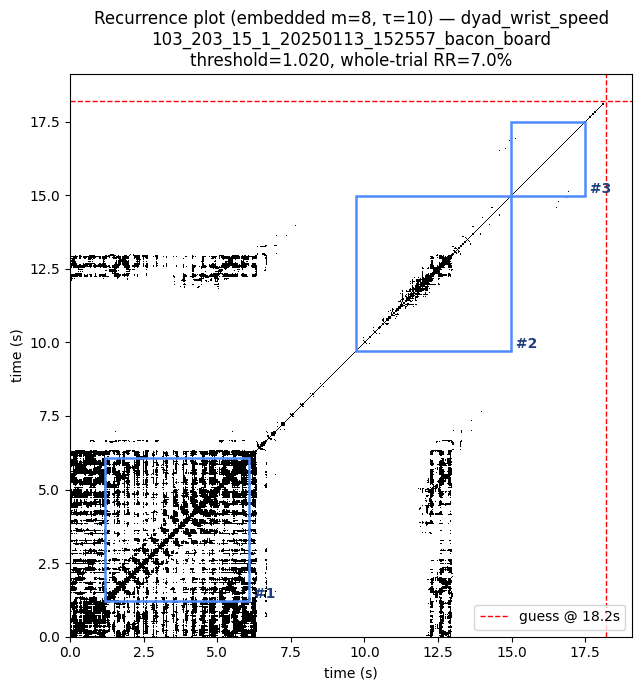

In [59]:
# --- demo: RQA of the speech envelope, attempts boxed on the RP ------------
rqa_metrics_env, rp_matrix_env, rp_t_env = rqa_by_attempts(
    DEMO_TRIAL, wrist_speed(DEMO_TRIAL), "time", "dyad_wrist_speed",
    time_unit="ms", label="dyad_wrist_speed")
plt.show()


In [60]:
# --- demo: RQA of the speech envelope, attempts boxed on the RP ------------
rqa_metrics_env, rp_matrix_env, rp_t_env = rqa_by_attempts(
    DEMO_TRIAL, wrist_speed(DEMO_TRIAL), "time", "envelope_norm",
    time_unit="ms", label="normalized speech envelope")
plt.show()


KeyError: "['envelope_norm'] not in index"

## Analysis table — RQA per attempt, both signals

Runs the RQA over **every** trial for both **clue-giver wrist speed** (gesture) and **normalized
speech envelope** (acoustics), scoring each attempt window, and writes `rqa_attempts_stats.csv`.

**One row per attempt** — the unit of analysis for statistical testing:

- *identity / design*: `trial_id`, `pair_id`, `condition` (board/ground), `target_word`,
  `clue_giver_id`, `guesser_id`
- *attempt*: `attempt_idx`, `n_attempts`, `start`, `end`, `duration`, `is_last_attempt`
- *trial context*: `guessed`, `guess_time`, `n_turntakes`
- *metrics*: `wrist_RR/DET/LAM/L_MAX` and `env_RR/DET/LAM/L_MAX` (+ `n_points`, `dt` per signal)

Note the observations are **not independent** — attempts nest within trials, trials within clue
givers/pairs — so a mixed-effects model with `clue_giver_id`/`pair_id` as random effects is the
appropriate test. `n_points` is included because RQA metrics are sensitive to window length; consider
controlling for it (or for `duration`).

In [ ]:
# ---- Analysis table: RQA of BOTH signals for every attempt window ----------
# Same method as the demos above — rqa_by_attempts(), embedded m=3, τ=5 — with the
# plotting turned off. One recurrence matrix per trial per signal (shared threshold
# within a trial), scored on each attempt window. Result: one row per attempt.

RQA_STATS_CSV = HERE / "rqa_attempts_stats.csv"
TARGET_RECURRENCE = 0.07
MAX_POINTS = 2000
DIM, DELAY = 3, 5

def rqa_all_trials(loader, value_col, name):
    """rqa_by_attempts over every trial in `attempts`; returns (long_df, skipped)."""
    frames, skipped = [], []
    trial_ids = sorted(attempts["trial_id"].unique())
    for i, tid in enumerate(trial_ids, 1):
        try:
            m, _, _ = rqa_by_attempts(tid, loader(tid), "time", value_col,
                                      time_unit="ms", target_recurrence=TARGET_RECURRENCE,
                                      max_points=MAX_POINTS,
                                      plot=False)
        except (FileNotFoundError, ValueError, KeyError) as e:
            skipped.append(f"{tid}: {e}")          # missing signal file / too short / flat
            continue
        if len(m):
            frames.append(m.assign(trial_id=tid))
        if i % 40 == 0 or i == len(trial_ids):
            print(f"  {name}: {i}/{len(trial_ids)} trials")
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return out, skipped

print("computing RQA per attempt window (embedded m=3, τ=5)...")
wrist_rqa, sk_w = rqa_all_trials(wrist_speed, "dyad_wrist_speed", "dyad_wrist_speed")
env_rqa,   sk_e = rqa_all_trials(speech_envelope, "envelope_norm", "envelope")

# Merge the two signals side by side on the attempt identity.
KEYS = ["trial_id", "attempt_idx"]
METRICS = ["RR", "DET", "LAM", "L_MAX", "n_points", "emb_dim", "emb_delay"]
SHARED = ["start", "end", "duration"]      # identical across signals -> keep one copy

w = wrist_rqa[KEYS + SHARED + METRICS].rename(columns={m: f"wrist_{m}" for m in METRICS})
e = env_rqa[KEYS + METRICS].rename(columns={m: f"env_{m}" for m in METRICS})
rqa_stats = w.merge(e, on=KEYS, how="outer")

# Attempt- and trial-level context useful for the models / filtering.
rqa_stats = rqa_stats.merge(
    attempts[["trial_id", "attempt_idx", "pair_id", "condition", "target_word",
              "clue_giver_id", "n_attempts"]],
    on=KEYS, how="left")
rqa_stats = rqa_stats.merge(
    summary[["trial_id", "guesser_id", "guessed", "guess_time", "n_turntakes"]],
    on="trial_id", how="left")
rqa_stats["is_last_attempt"] = rqa_stats["attempt_idx"] == rqa_stats["n_attempts"]

rqa_stats = rqa_stats.sort_values(KEYS).reset_index(drop=True)
rqa_stats.to_csv(RQA_STATS_CSV, index=False)

print(f"\nwrote {RQA_STATS_CSV.name}: {len(rqa_stats)} attempt rows from "
      f"{rqa_stats.trial_id.nunique()} trials, {rqa_stats.clue_giver_id.nunique()} clue givers")
if sk_w or sk_e:
    print(f"skipped — wrist: {len(sk_w)}, envelope: {len(sk_e)}")
print(f"columns: {list(rqa_stats.columns)}")
print("\nmean by condition:")
print(rqa_stats.groupby("condition")[["duration", "wrist_RR", "wrist_DET",
                                      "env_RR", "env_DET"]].mean().round(3).to_string())
rqa_stats.head()


computing RQA per attempt window (embedded m=3, τ=5)...
  dyad_wrist_speed: 40/114 trials
  dyad_wrist_speed: 80/114 trials
  envelope: 40/114 trials
  envelope: 80/114 trials
  envelope: 114/114 trials

wrote rqa_attempts_stats.csv: 183 attempt rows from 114 trials, 6 clue givers
skipped — wrist: 7, envelope: 0
columns: ['trial_id', 'attempt_idx', 'start', 'end', 'duration', 'wrist_RR', 'wrist_DET', 'wrist_LAM', 'wrist_L_MAX', 'wrist_n_points', 'wrist_emb_dim', 'wrist_emb_delay', 'env_RR', 'env_DET', 'env_LAM', 'env_L_MAX', 'env_n_points', 'env_emb_dim', 'env_emb_delay', 'pair_id', 'condition', 'target_word', 'clue_giver_id', 'n_attempts', 'guesser_id', 'guessed', 'guess_time', 'n_turntakes', 'is_last_attempt']

mean by condition:
           duration  wrist_RR  wrist_DET  env_RR  env_DET
condition                                                
board         8.871     0.103      0.563   0.076    0.819
ground        8.159     0.132      0.571   0.088    0.852


,trial_id,attempt_idx,start,end,duration,wrist_RR,wrist_DET,wrist_LAM,wrist_L_MAX,wrist_n_points,...,pair_id,condition,target_word,clue_giver_id,n_attempts,guesser_id,guessed,guess_time,n_turntakes,is_last_attempt
0,103_203_12_1_20250113_152455_doughnut_board,1,1.01,13.79,12.78,0.0675,0.4900,0.7055,1.9000,383.0,...,103_203,board,doughnut,103,1,203.0,True,14.46,0,True
1,103_203_13_1_20250113_152513_spinach_board,1,2.80,13.80,11.00,0.0300,0.8299,0.8880,1.7333,330.0,...,103_203,board,spinach,103,1,203.0,True,14.67,1,True
2,103_203_14_1_20250113_152536_balloon_board,1,2.61,18.61,16.00,0.0654,0.6557,0.8097,5.6667,480.0,...,103_203,board,balloon,103,2,203.0,False,NaN,2,False
3,103_203_14_1_20250113_152536_balloon_board,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,103_203,board,balloon,103,2,203.0,False,NaN,2,True
4,103_203_15_1_20250113_152557_bacon_board,1,1.20,6.08,4.88,0.3893,0.8156,0.8983,4.8667,147.0,...,103_203,board,bacon,103,3,203.0,True,18.19,4,False


In [ ]:
from rqa_attempts_embedded import rqa_for_trial, load_wrist_speed, load_envelope

# ---- Analysis table: RQA of BOTH signals for every attempt window ----------
# One recurrence matrix per trial per signal (shared threshold within a trial),
# scored on each attempt window. Result: one row per attempt, wide across signals.

RQA_STATS_CSV = HERE / "rqa_attempts_stats.csv"
TARGET_RECURRENCE = 0.07
MAX_POINTS = 2000

def rqa_all_trials(loader, name):
    rows, skipped = [], []
    trials = list(attempts.groupby("trial_id", sort=True))
    for i, (tid, sub) in enumerate(trials, 1):
        r, err = rqa_for_trial(tid, sub, loader, TARGET_RECURRENCE, MAX_POINTS, dim=3, delay=5)
        rows.extend(r)
        if err:
            skipped.append(err)
        if i % 40 == 0 or i == len(trials):
            print(f"  {name}: {i}/{len(trials)} trials")
    return pd.DataFrame(rows), skipped

print("computing RQA per attempt window...")
wrist_rqa, sk_w = rqa_all_trials(load_wrist_speed, "wrist_speed")
env_rqa, sk_e = rqa_all_trials(load_envelope, "envelope")

# Merge the two signals side by side on the attempt identity.
KEYS = ["trial_id", "pair_id", "condition", "target_word", "clue_giver_id",
        "attempt_idx", "n_attempts", "start", "end", "duration"]
METRICS = ["RR", "DET", "LAM", "L_MAX", "n_points", "dt"]

w = wrist_rqa[KEYS + METRICS].rename(columns={m: f"wrist_{m}" for m in METRICS})
e = env_rqa[KEYS + METRICS].rename(columns={m: f"env_{m}" for m in METRICS})
rqa_stats = w.merge(e, on=KEYS, how="outer")

# Trial-level context useful for the models / filtering.
rqa_stats = rqa_stats.merge(
    summary[["trial_id", "guesser_id", "guessed", "guess_time", "n_turntakes"]],
    on="trial_id", how="left")
rqa_stats["is_last_attempt"] = rqa_stats["attempt_idx"] == rqa_stats["n_attempts"]

rqa_stats = rqa_stats.sort_values(["trial_id", "attempt_idx"]).reset_index(drop=True)
rqa_stats.to_csv(RQA_STATS_CSV, index=False)

print(f"\nwrote {RQA_STATS_CSV.name}: {len(rqa_stats)} attempt rows from "
      f"{rqa_stats.trial_id.nunique()} trials, {rqa_stats.clue_giver_id.nunique()} clue givers")
if sk_w or sk_e:
    print(f"skipped — wrist: {len(sk_w)}, envelope: {len(sk_e)}")
print(f"columns: {list(rqa_stats.columns)}")
print("\nmean by condition:")
print(rqa_stats.groupby("condition")[["duration", "wrist_RR", "wrist_DET",
                                      "env_RR", "env_DET"]].mean().round(3).to_string())
rqa_stats.head()

two = rqa_stats[rqa_stats["n_attempts"]==2]
two.head()

computing RQA per attempt window...
  wrist_speed: 40/114 trials
  wrist_speed: 80/114 trials
  wrist_speed: 114/114 trials
  envelope: 40/114 trials
  envelope: 80/114 trials
  envelope: 114/114 trials

wrote rqa_attempts_stats.csv: 185 attempt rows from 114 trials, 6 clue givers
columns: ['trial_id', 'pair_id', 'condition', 'target_word', 'clue_giver_id', 'attempt_idx', 'n_attempts', 'start', 'end', 'duration', 'wrist_RR', 'wrist_DET', 'wrist_LAM', 'wrist_L_MAX', 'wrist_n_points', 'wrist_dt', 'env_RR', 'env_DET', 'env_LAM', 'env_L_MAX', 'env_n_points', 'env_dt', 'guesser_id', 'guessed', 'guess_time', 'n_turntakes', 'is_last_attempt']

mean by condition:
           duration  wrist_RR  wrist_DET  env_RR  env_DET
condition                                                
board         9.572     0.077      0.484   0.054    0.828
ground        8.135     0.103      0.520   0.057    0.818


,trial_id,pair_id,condition,target_word,clue_giver_id,attempt_idx,n_attempts,start,end,duration,...,env_DET,env_LAM,env_L_MAX,env_n_points,env_dt,guesser_id,guessed,guess_time,n_turntakes,is_last_attempt
2,103_203_14_1_20250113_152536_balloon_board,103_203,board,balloon,103,1,2,2.61,18.61,16.00,...,0.9392,0.9632,0.792,1333,0.012,203.0,False,NaN,2,False
3,103_203_14_1_20250113_152536_balloon_board,103_203,board,balloon,103,2,2,20.61,22.61,2.00,...,0.9697,0.9945,1.044,111,0.012,203.0,False,NaN,2,True
12,103_203_21_1_20250113_152824_tiger_board,103_203,board,tiger,103,1,2,0.00,36.12,36.12,...,0.9571,0.9773,3.768,1505,0.024,203.0,True,44.12,3,False
13,103_203_21_1_20250113_152824_tiger_board,103_203,board,tiger,103,2,2,37.00,43.00,6.00,...,0.1758,0.3104,0.144,250,0.024,203.0,True,44.12,3,True
14,103_203_23_1_20250113_152946_trumpet_ground,103_203,ground,trumpet,203,1,2,1.74,26.17,24.43,...,0.9301,0.9640,2.736,1357,0.018,103.0,False,NaN,3,False


In [ ]:
two.shape

(38, 27)

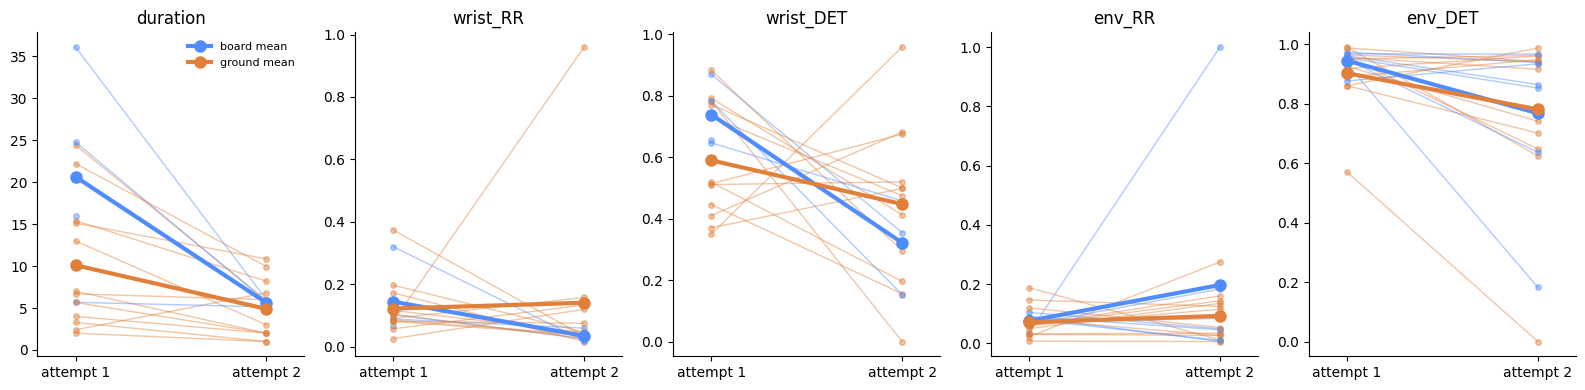

In [ ]:
import matplotlib.pyplot as plt

two = rqa_stats[rqa_stats['n_attempts'] == 2]
METRICS = ["duration", "wrist_RR", "wrist_DET", "env_RR", "env_DET"]
colors = {"board": "#4f8cff", "ground": "#e0803a"}

fig, axes = plt.subplots(1, len(METRICS), figsize=(3.2 * len(METRICS), 4))
for ax, m in zip(axes, METRICS):
    w = two.pivot_table(index=["trial_id", "condition"], columns="attempt_idx",
                        values=m).reset_index()
    for _, r in w.iterrows():                        # one thin line per trial
        ax.plot([1, 2], [r[1], r[2]], color=colors.get(r["condition"], "0.5"),
                alpha=0.45, marker="o", ms=4, lw=1)
    for cond, sub in w.groupby("condition"):         # thick condition means
        ax.plot([1, 2], [sub[1].mean(), sub[2].mean()], color=colors[cond],
                lw=3, marker="o", ms=8, label=f"{cond} mean")
    ax.set_xticks([1, 2]); ax.set_xticklabels(["attempt 1", "attempt 2"])
    ax.set_xlim(0.8, 2.2); ax.set_title(m)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()


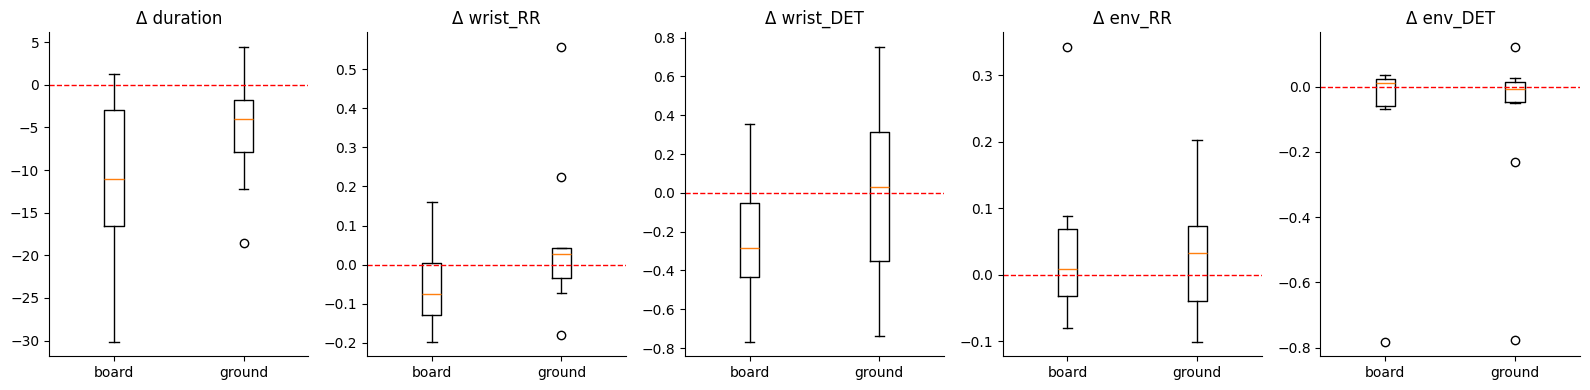

In [ ]:
w = two.pivot_table(index=["trial_id", "condition"], columns="attempt_idx",
                    values=METRICS).reset_index()
delta = pd.DataFrame({"condition": w["condition"]})
for m in METRICS:
    delta[m] = w[(m, 2)] - w[(m, 1)]                 # attempt 2 − attempt 1

fig, axes = plt.subplots(1, len(METRICS), figsize=(3.2 * len(METRICS), 4))
for ax, m in zip(axes, METRICS):
    groups = [delta.loc[delta.condition == c, m].dropna() for c in ["board", "ground"]]
    ax.boxplot(groups, tick_labels=["board", "ground"])
    ax.axhline(0, color="red", ls="--", lw=1)        # no-change reference
    ax.set_title(f"Δ {m}")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


## Export ELAN files for the DIMS app

Writes one `.eaf` per trial into `dims/assets/elan/{trial_id}.eaf` — the path the DIMS dashboard
reads. Each file has two tiers:

- **`clue_giver_attempts`** — one annotation per attempt, spanning its interval, labelled `attempt N`.
- **`guess`** — the segment where the target word is first said, labelled `guess: <target_word>`.

Trials with no attempts *and* no guess are skipped (an EAF with no annotations would error in DIMS).
For the tab to appear, `dims/config.json` needs `"include_elan": true`.

In [ ]:
# import xml.sax.saxutils as sx

# # ---- Write ELAN (.eaf) files for the DIMS app: attempts + guess ------------
# ELAN_DIR = HERE / "dims" / "assets" / "elan"     # DIMS reads assets/elan/{videoID}.eaf

# def guess_span(trial_id):
#     """(start, end) of the first segment containing the target word, else None."""
#     t = df[df.trial_id == trial_id]
#     target = t["target_word"].iloc[0]
#     hits = t[t["text"].apply(lambda x: says_target(x, target))].sort_values("start")
#     if not len(hits):
#         return None
#     r = hits.iloc[0]
#     return float(r.start), float(r.end)


# def write_eaf(trial_id, out_dir=ELAN_DIR):
#     """One .eaf per trial: a 'clue_giver_attempts' tier and a 'guess' tier."""
#     iv = attempt_intervals(trial_id)
#     gs = guess_span(trial_id)
#     target = summary.loc[summary.trial_id == trial_id, "target_word"].iloc[0]

#     tiers = {}
#     if len(iv):
#         tiers["clue_giver_attempts"] = [
#             (r.start, r.end, f"attempt {int(r.attempt_idx)}") for r in iv.itertuples(index=False)
#         ]
#     if gs:
#         tiers["guess"] = [(gs[0], gs[1], f"guess: {target}")]
#     if not tiers:
#         return False                                   # nothing to annotate

#     slots = {}                                         # ms -> slot id
#     def slot(t_sec):
#         ms = int(round(t_sec * 1000))
#         if ms not in slots:
#             slots[ms] = f"ts{len(slots) + 1}"
#         return slots[ms]

#     aid, tier_xml = 0, []
#     for tier_id, anns in tiers.items():
#         rows = []
#         for s, e, val in anns:
#             aid += 1
#             r1, r2 = slot(s), slot(e)
#             rows.append(
#                 "      <ANNOTATION>\n"
#                 f'        <ALIGNABLE_ANNOTATION ANNOTATION_ID="a{aid}" '
#                 f'TIME_SLOT_REF1="{r1}" TIME_SLOT_REF2="{r2}">\n'
#                 f"          <ANNOTATION_VALUE>{sx.escape(val)}</ANNOTATION_VALUE>\n"
#                 "        </ALIGNABLE_ANNOTATION>\n"
#                 "      </ANNOTATION>"
#             )
#         tier_xml.append(
#             f'  <TIER LINGUISTIC_TYPE_REF="default" TIER_ID="{sx.escape(tier_id)}">\n'
#             + "\n".join(rows) + "\n  </TIER>"
#         )

#     slot_xml = "\n".join(f'    <TIME_SLOT TIME_SLOT_ID="{sid}" TIME_VALUE="{ms}"/>'
#                          for ms, sid in sorted(slots.items()))
#     xml = "\n".join([
#         '<?xml version="1.0" encoding="UTF-8"?>',
#         '<ANNOTATION_DOCUMENT AUTHOR="BalanceCorpus turntaking" FORMAT="3.0" VERSION="3.0"'
#         ' xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"'
#         ' xsi:noNamespaceSchemaLocation="http://www.mpi.nl/tools/elan/EAFv3.0.xsd">',
#         '  <HEADER TIME_UNITS="milliseconds"/>',
#         "  <TIME_ORDER>", slot_xml, "  </TIME_ORDER>",
#         *tier_xml,
#         '  <LINGUISTIC_TYPE LINGUISTIC_TYPE_ID="default" TIME_ALIGNABLE="true"/>',
#         "</ANNOTATION_DOCUMENT>",
#     ])
#     out_dir.mkdir(parents=True, exist_ok=True)
#     (out_dir / f"{trial_id}.eaf").write_text(xml, encoding="utf-8")
#     return True


# written = sum(write_eaf(t) for t in summary["trial_id"])
# skipped = len(summary) - written
# print(f"wrote {written} .eaf files to {ELAN_DIR}" + (f"  ({skipped} skipped: no attempts and no guess)" if skipped else ""))

# # validate: every file is well-formed XML with at least one alignable annotation
# import xml.etree.ElementTree as ET
# bad = []
# for p in sorted(ELAN_DIR.glob("*.eaf")):
#     try:
#         root = ET.parse(p).getroot()
#         if not list(root.iter("ALIGNABLE_ANNOTATION")):
#             bad.append((p.name, "no annotations"))
#     except ET.ParseError as e:
#         bad.append((p.name, str(e)))
# print("validated:", len(list(ELAN_DIR.glob('*.eaf'))), "files |", "all OK" if not bad else f"PROBLEMS: {bad[:3]}")

In [61]:
import json, xml.sax.saxutils as sx
import numpy as np, pandas as pd

from rqa_attempts_embedded import decimate, embedded_recurrence_matrix
from step_RQA import (matrix_to_sparse_format, downsample_for_visualization,
                      compute_windowed_metrics)

# ---- Export to the DIMS app: recurrence plots + attempt segments (ELAN) ----
# RPs  -> dims/assets/rqa/{trial_id}_rqa_data.json   (MERGED into the existing file)
# segs -> dims/assets/elan/{trial_id}.eaf            (attempts + guess tiers)

DIMS = HERE / "dims"
RQA_DIR, ELAN_DIR = DIMS / "assets" / "rqa", DIMS / "assets" / "elan"
CONFIG = DIMS / "config.json"

DIM, DELAY = 3, 5                 # same fixed embedding as the demos above
TARGET_RECURRENCE, MAX_POINTS = 0.07, 2000
VIS_MAX_POINTS = 500              # RP sent to the browser; sparse_matrix is O(n^2 * RR)
WINDOW_SEC, STEP_SEC = 5.0, 0.5   # sliding window for the metric strip

SIGNALS = {                       # data_type key -> (loader, value_col)
    "attempts_wrist_speed": (wrist_speed, "dyad_wrist_speed"),
    "attempts_envelope":    (speech_envelope, "envelope_norm"),
}


def rp_payload(trial_id, loader, value_col, data_type):
    """One embedded RP for the trial, shaped like step_RQA's per-data_type block."""
    s = loader(trial_id)[["time", value_col]].dropna()
    t = s["time"].to_numpy() / 1000.0
    v = s[value_col].to_numpy()
    t, v = decimate(t, v, max_points=MAX_POINTS)
    if len(t) < 20 or np.std(v) == 0:
        raise ValueError("signal too short or flat")

    matrix, threshold, rec_rate, n_vec = embedded_recurrence_matrix(
        v, DIM, DELAY, TARGET_RECURRENCE)
    t_emb, v_emb = t[:n_vec], v[:n_vec]        # vector i is anchored at t[i]

    windowed = compute_windowed_metrics(matrix, t_emb, window_sec=WINDOW_SEC,
                                        step_sec=STEP_SEC)
    data_vis, time_vis, matrix_vis = downsample_for_visualization(
        v_emb, t_emb, matrix, max_points=VIS_MAX_POINTS)

    return {
        "data_type": data_type,
        "dimensions": [value_col],
        "threshold": float(threshold),
        "recurrence_rate": float(rec_rate),
        "time_range": [float(t_emb[0]), float(t_emb[-1])],
        "windowed_metrics": windowed,
        "visualization": {
            "time": np.asarray(time_vis).tolist(),
            "data": np.asarray(data_vis).tolist(),
            "matrix_size": len(time_vis),
            "sparse_matrix": matrix_to_sparse_format(matrix_vis),
        },
        "full_data": {"n_points": int(n_vec),
                      "time_range": [float(t_emb[0]), float(t_emb[-1])],
                      "emb_dim": DIM, "emb_delay": DELAY},
    }


def guess_span(trial_id):
    """(start, end) of the first segment containing the target word, else None."""
    t = df[df.trial_id == trial_id]
    target = t["target_word"].iloc[0]
    hits = t[t["text"].apply(lambda x: says_target(x, target))].sort_values("start")
    if not len(hits):
        return None
    r = hits.iloc[0]
    return float(r.start), float(r.end)


def write_eaf(trial_id):
    """One .eaf per trial: a 'clue_giver_attempts' tier and a 'guess' tier."""
    iv, gs = attempt_intervals(trial_id), guess_span(trial_id)
    target = summary.loc[summary.trial_id == trial_id, "target_word"].iloc[0]

    tiers = {}
    if len(iv):
        tiers["clue_giver_attempts"] = [(r.start, r.end, f"attempt {int(r.attempt_idx)}")
                                        for r in iv.itertuples(index=False)]
    if gs:
        tiers["guess"] = [(gs[0], gs[1], f"guess: {target}")]
    if not tiers:
        return False                                   # an empty EAF errors in DIMS

    slots = {}
    def slot(t_sec):
        ms = int(round(t_sec * 1000))
        slots.setdefault(ms, f"ts{len(slots) + 1}")
        return slots[ms]

    aid, tier_xml = 0, []
    for tier_id, anns in tiers.items():
        rows = []
        for s, e, val in anns:
            aid += 1
            r1, r2 = slot(s), slot(e)
            rows.append("      <ANNOTATION>\n"
                        f'        <ALIGNABLE_ANNOTATION ANNOTATION_ID="a{aid}" '
                        f'TIME_SLOT_REF1="{r1}" TIME_SLOT_REF2="{r2}">\n'
                        f"          <ANNOTATION_VALUE>{sx.escape(val)}</ANNOTATION_VALUE>\n"
                        "        </ALIGNABLE_ANNOTATION>\n"
                        "      </ANNOTATION>")
        tier_xml.append(f'  <TIER LINGUISTIC_TYPE_REF="default" TIER_ID="{sx.escape(tier_id)}">\n'
                        + "\n".join(rows) + "\n  </TIER>")

    slot_xml = "\n".join(f'    <TIME_SLOT TIME_SLOT_ID="{sid}" TIME_VALUE="{ms}"/>'
                         for ms, sid in sorted(slots.items()))
    xml = "\n".join([
        '<?xml version="1.0" encoding="UTF-8"?>',
        '<ANNOTATION_DOCUMENT AUTHOR="BalanceCorpus turntaking" FORMAT="3.0" VERSION="3.0"'
        ' xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"'
        ' xsi:noNamespaceSchemaLocation="http://www.mpi.nl/tools/elan/EAFv3.0.xsd">',
        '  <HEADER TIME_UNITS="milliseconds"/>',
        "  <TIME_ORDER>", slot_xml, "  </TIME_ORDER>", *tier_xml,
        '  <LINGUISTIC_TYPE LINGUISTIC_TYPE_ID="default" TIME_ALIGNABLE="true"/>',
        "</ANNOTATION_DOCUMENT>"])
    ELAN_DIR.mkdir(parents=True, exist_ok=True)
    (ELAN_DIR / f"{trial_id}.eaf").write_text(xml, encoding="utf-8")
    return True


# --- run -------------------------------------------------------------------
RQA_DIR.mkdir(parents=True, exist_ok=True)
trial_ids = sorted(attempts["trial_id"].unique())
n_rp, n_eaf, skipped = 0, 0, []

for i, tid in enumerate(trial_ids, 1):
    # RPs: read-modify-write so the existing wrists_hands blocks survive.
    path = RQA_DIR / f"{tid}_rqa_data.json"
    doc = json.loads(path.read_text()) if path.exists() else {"video_id": tid, "rqa_data": {}}
    doc.setdefault("rqa_data", {})
    wrote_any = False
    for data_type, (loader, value_col) in SIGNALS.items():
        try:
            doc["rqa_data"][data_type] = rp_payload(tid, loader, value_col, data_type)
            wrote_any = True
        except (FileNotFoundError, ValueError, KeyError) as e:
            skipped.append(f"{tid} / {data_type}: {e}")
    if wrote_any:
        path.write_text(json.dumps(doc))
        n_rp += 1
    n_eaf += write_eaf(tid)
    if i % 20 == 0 or i == len(trial_ids):
        print(f"  {i}/{len(trial_ids)} trials")

# Register the new RP tabs and the ELAN tab in the app config.
cfg = json.loads(CONFIG.read_text())
cfg["include_RQA"] = sorted(set(cfg.get("include_RQA", [])) | set(SIGNALS))
cfg["include_elan"] = True
CONFIG.write_text(json.dumps(cfg, indent=2))

print(f"\nRP json:  {n_rp} files -> {RQA_DIR.relative_to(HERE)}")
print(f"ELAN:     {n_eaf} files -> {ELAN_DIR.relative_to(HERE)}")
print(f"config:   include_RQA = {cfg['include_RQA']}, include_elan = {cfg['include_elan']}")
if skipped:
    print(f"\n{len(skipped)} skipped:")
    for s in skipped[:8]:
        print("  ", s)

# validate: EAFs parse and carry annotations; RP json has both new data types
import xml.etree.ElementTree as ET
bad = []
for p in sorted(ELAN_DIR.glob("*.eaf")):
    try:
        if not list(ET.parse(p).getroot().iter("ALIGNABLE_ANNOTATION")):
            bad.append((p.name, "no annotations"))
    except ET.ParseError as e:
        bad.append((p.name, str(e)))
missing = [p.name for p in sorted(RQA_DIR.glob("*_rqa_data.json"))
           if not set(SIGNALS) <= set(json.loads(p.read_text()).get("rqa_data", {}))]
print(f"\nvalidated — eaf: {'all OK' if not bad else f'PROBLEMS {bad[:3]}'} | "
      f"rqa json without the new types: {len(missing)}")


  Downsampled from 513 to 513 points for visualization
  Downsampled from 1732 to 578 points for visualization
  Downsampled from 516 to 516 points for visualization
  Downsampled from 1741 to 581 points for visualization
  Downsampled from 653 to 653 points for visualization
  Downsampled from 1829 to 610 points for visualization
  Downsampled from 605 to 605 points for visualization
  Downsampled from 1697 to 566 points for visualization
  Downsampled from 1924 to 642 points for visualization
  Downsampled from 876 to 876 points for visualization
  Downsampled from 1834 to 612 points for visualization
  Downsampled from 1976 to 659 points for visualization
  Downsampled from 1816 to 606 points for visualization
  Downsampled from 660 to 660 points for visualization
  Downsampled from 1854 to 618 points for visualization
  Downsampled from 1417 to 709 points for visualization
  Downsampled from 1973 to 658 points for visualization
  Downsampled from 988 to 988 points for visualization

In [62]:
import json, shutil
import numpy as np, pandas as pd

from rqa_attempts_embedded import decimate, embedded_recurrence_matrix
from step_RQA import (matrix_to_sparse_format, downsample_for_visualization,
                      compute_windowed_metrics)

# ---- Build DIMS assets from scratch: attempts_wrist_speed + attempts_envelope ----
# timeseries tab -> assets/timeseries/{tid}_{channel}.csv   (Time,<channel>)
# RQA tab        -> assets/rqa/{tid}_rqa_data.json          (embedded RP, m=3 τ=5)
# ELAN tab       -> assets/elan/{tid}.eaf                   (attempts + guess)
#
# FRESH=True deletes the existing timeseries CSVs (envelope/f0/sway) and RQA JSONs
# (wrists_hands/wrists_velocity_hands). They are NOT in git — restore with
# `python dims/build_assets.py`. Videos and ELAN are left alone.
FRESH = True

DIMS = HERE / "dims"
TS_OUT, RQA_OUT = DIMS / "assets" / "timeseries", DIMS / "assets" / "rqa"
ELAN_DIR, VID_OUT = DIMS / "assets" / "elan", DIMS / "assets" / "videos"
CONFIG = DIMS / "config.json"

DIM, DELAY = 3, 5                 # fixed embedding, same as the demos
TARGET_RECURRENCE, MAX_POINTS = 0.07, 2000
VIS_MAX_POINTS = 500              # RP sent to the browser (sparse_matrix is O(n^2 * RR))
WINDOW_SEC, STEP_SEC = 5.0, 0.5

CHANNELS = {                      # channel name -> (loader, value_col in that loader)
    "attempts_wrist_speed": (wrist_speed, "dyad_wrist_speed"),
    "attempts_envelope":    (speech_envelope, "envelope_norm"),
}


def signal_for(trial_id, loader, value_col):
    """Decimated (time_s, value) — the exact series the RP is built on."""
    s = loader(trial_id)[["time", value_col]].dropna()
    t, v = decimate(s["time"].to_numpy() / 1000.0, s[value_col].to_numpy(),
                    max_points=MAX_POINTS)
    if len(t) < 20 or np.std(v) == 0:
        raise ValueError("signal too short or flat")
    return t, v


def rp_payload(t, v, channel):
    """Embedded RP for one channel, in step_RQA's per-data_type schema."""
    matrix, threshold, rec_rate, n_vec = embedded_recurrence_matrix(
        v, DIM, DELAY, TARGET_RECURRENCE)
    t_emb, v_emb = t[:n_vec], v[:n_vec]        # vector i is anchored at t[i]

    windowed = compute_windowed_metrics(matrix, t_emb, window_sec=WINDOW_SEC,
                                        step_sec=STEP_SEC)
    data_vis, time_vis, matrix_vis = downsample_for_visualization(
        v_emb, t_emb, matrix, max_points=VIS_MAX_POINTS)
    return {
        "data_type": channel,
        "dimensions": [channel],
        "threshold": float(threshold),
        "recurrence_rate": float(rec_rate),
        "time_range": [float(t_emb[0]), float(t_emb[-1])],
        "windowed_metrics": windowed,
        "visualization": {
            "time": np.asarray(time_vis).tolist(),
            "data": np.asarray(data_vis).tolist(),
            "matrix_size": len(time_vis),
            "sparse_matrix": matrix_to_sparse_format(matrix_vis),
        },
        "full_data": {"n_points": int(n_vec), "emb_dim": DIM, "emb_delay": DELAY,
                      "time_range": [float(t_emb[0]), float(t_emb[-1])]},
    }


# --- run -------------------------------------------------------------------
for d in (TS_OUT, RQA_OUT, ELAN_DIR):
    d.mkdir(parents=True, exist_ok=True)
if FRESH:
    n_old = len(list(TS_OUT.glob("*.csv"))) + len(list(RQA_OUT.glob("*_rqa_data.json")))
    for old in TS_OUT.glob("*.csv"):
        old.unlink()
    for old in RQA_OUT.glob("*_rqa_data.json"):
        old.unlink()
    print(f"cleared {n_old} old asset files (rebuild originals: python dims/build_assets.py)")

video_ids, data_types, warnings = [], {}, []
trial_ids = sorted(attempts["trial_id"].unique())

for i, tid in enumerate(trial_ids, 1):
    if not (VID_OUT / f"{tid}.mp4").exists():
        warnings.append(f"{tid}: no video in assets/videos, skipping trial")
        continue

    channels, rqa_blocks = [], {}
    for channel, (loader, value_col) in CHANNELS.items():
        try:
            t, v = signal_for(tid, loader, value_col)
        except (FileNotFoundError, ValueError, KeyError) as e:
            warnings.append(f"{tid}: no {channel} ({e})")
            continue
        pd.DataFrame({"Time": np.round(t, 4), channel: v}).to_csv(
            TS_OUT / f"{tid}_{channel}.csv", index=False, na_rep="")
        rqa_blocks[channel] = rp_payload(t, v, channel)
        channels.append(channel)

    if not channels:
        warnings.append(f"{tid}: no channels at all, skipping trial")
        continue
    (RQA_OUT / f"{tid}_rqa_data.json").write_text(
        json.dumps({"video_id": tid, "rqa_data": rqa_blocks}))
    write_eaf(tid)                     # attempts + guess tiers (helper from the cell above)

    video_ids.append(tid)
    data_types[tid] = channels
    if i % 20 == 0 or i == len(trial_ids):
        print(f"  {i}/{len(trial_ids)} trials")

cfg = json.loads(CONFIG.read_text()) if CONFIG.exists() else {}
cfg.update({
    "videoIDs": video_ids,
    "dataTypes": data_types,
    "include_RQA": sorted(CHANNELS),
    "include_elan": True,
    "defaultWindowSize": int(WINDOW_SEC),
})
CONFIG.write_text(json.dumps(cfg, indent=2))

print(f"\ntrials in config: {len(video_ids)}")
print(f"timeseries: {len(list(TS_OUT.glob('*.csv')))} csv | "
      f"rqa: {len(list(RQA_OUT.glob('*_rqa_data.json')))} json | "
      f"elan: {len(list(ELAN_DIR.glob('*.eaf')))} eaf")
print(f"include_RQA = {cfg['include_RQA']}")
if warnings:
    print(f"\n{len(warnings)} warnings:")
    for w in warnings[:10]:
        print("  ", w)


cleared 480 old asset files (rebuild originals: python dims/build_assets.py)
  Downsampled from 513 to 513 points for visualization
  Downsampled from 1732 to 578 points for visualization
  Downsampled from 516 to 516 points for visualization
  Downsampled from 1741 to 581 points for visualization
  Downsampled from 653 to 653 points for visualization
  Downsampled from 1829 to 610 points for visualization
  Downsampled from 605 to 605 points for visualization
  Downsampled from 1697 to 566 points for visualization
  Downsampled from 1924 to 642 points for visualization
  Downsampled from 876 to 876 points for visualization
  Downsampled from 1834 to 612 points for visualization
  Downsampled from 1976 to 659 points for visualization
  Downsampled from 1816 to 606 points for visualization
  Downsampled from 660 to 660 points for visualization
  Downsampled from 1854 to 618 points for visualization
  Downsampled from 1417 to 709 points for visualization
  Downsampled from 1973 to 658 po